# Poincaré vs Lorentz Embeddings: same objective, two charts

:doc:`Poincaré Embeddings <../methods/poincare_embeddings>` and
:doc:`Lorentz Embeddings <../methods/lorentz>` optimise the **same** soft-ranking
objective (Nickel & Kiela). They differ only in *which model of hyperbolic space*
the optimisation runs in — the Poincaré ball ($\|x\|<1$) or the Lorentz
hyperboloid ($\langle x,x\rangle_{\mathcal L}=-1$). The two models are isometric:
they describe the same geometry.

So when does the choice matter? This notebook answers that honestly:

1. **On a typical graph, it doesn't.** Both embedders recover the same hierarchy.
   In hypeGRL they even share the same optimiser (geoopt Riemannian Adam with an
   exact retraction), so the dramatic low-dimensional gap reported in the Lorentz
   paper — which came from comparing an *exact* Lorentz optimiser against a
   *first-order-approximate* Poincaré one — is largely neutralised.
2. **The Lorentz representation has a genuine numerical edge**: the Poincaré
   distance loses precision near the boundary, and past a hyperbolic radius of
   $\approx 16.8$ the ball simply *cannot tell points apart* in ``float64``. The
   hyperboloid has no such ceiling. That is the benefit worth knowing about, and
   we demonstrate it directly.

In [1]:
# !pip install git+https://github.com/cicadaUY/hypeGRL
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

from hypegrl.embedders.poincare_embeddings import PoincareEmbeddingsEmbedder
from hypegrl.embedders.lorentz_embeddings import LorentzEmbeddingsEmbedder
from hypegrl.manifolds.poincare import POINCARE_BALL
from hypegrl.manifolds.lorentz import LORENTZ
from hypegrl.visualization import plot_polar

torch.set_default_dtype(torch.float64)

## 1. Both embed the same tree

A balanced binary tree of depth 5 (63 nodes) is a clean hierarchy: the root is
the most *general* node and leaves the most *specific*. A good hyperbolic
embedding places the root near the origin and pushes leaves toward the boundary,
so the **embedding norm tracks depth** (the paper's *generality = norm*).

We fit each method near its recommended settings and draw the result on the
Poincaré disk (radius = distance from the origin), colouring nodes by their depth
in the tree.

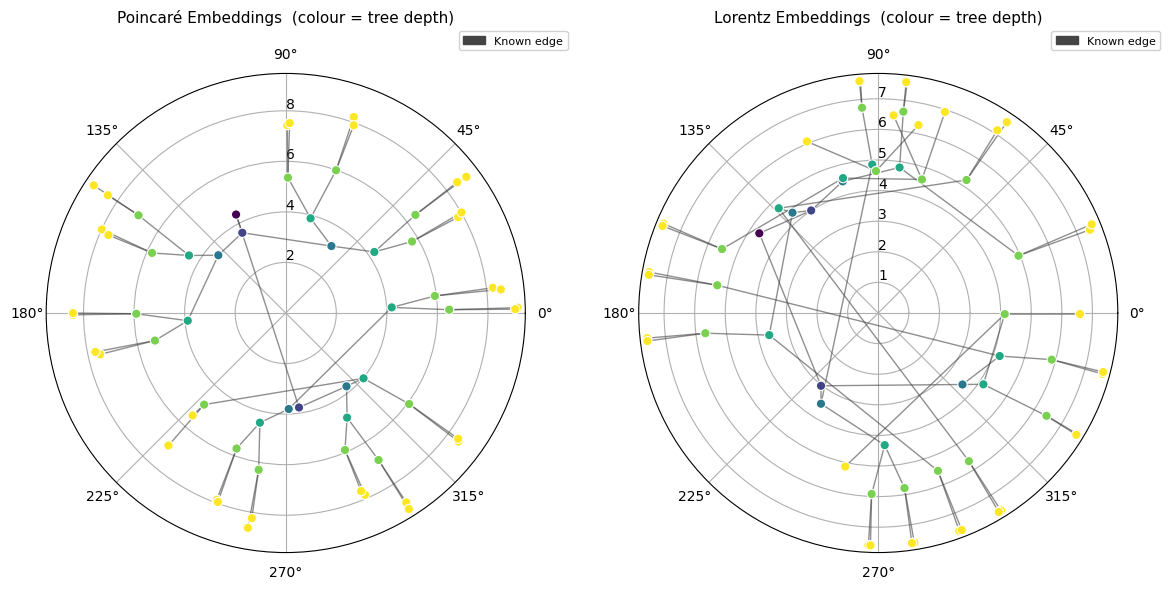

In [2]:
tree = nx.balanced_tree(2, 5)
depth = nx.shortest_path_length(tree, 0)
depth_vec = np.array([depth[n] for n in tree.nodes()])

pe = PoincareEmbeddingsEmbedder(
    d=2, loss="ranking", lr_X=0.1, n_steps=1500, burnin=100,
    log_every=0, random_state=0,
).fit(tree)
lo = LorentzEmbeddingsEmbedder(
    d=2, lr_X=0.5, n_steps=2500, log_every=0, random_state=0,
).fit(tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": "polar"})
for ax, emb, name in [(axes[0], pe, "Poincaré Embeddings"),
                      (axes[1], lo, "Lorentz Embeddings")]:
    plot_polar(tree, emb.embeddings(), nodes=emb.nodes(), node_color=depth_vec,
               ax=ax, show_node_labels=False, node_size=45,
               title=f"{name}  (colour = tree depth)")
plt.tight_layout()
plt.show()

Both look the way a tree embedding should: the root sits at the centre and each
successive level fans out toward the boundary. Let us quantify two things —
**reconstruction** (can we recover the edges from distances?) and **hierarchy
recovery** (does the norm track depth?).

In [3]:
def reconstruction_auc(emb, G):
    D = emb.decode(emb.embeddings())          # pairwise hyperbolic distances
    nodes = emb.nodes(); N = len(nodes)
    y_true, y_score = [], []
    for i in range(N):
        for j in range(i + 1, N):
            y_true.append(1 if G.has_edge(nodes[i], nodes[j]) else 0)
            y_score.append(-D[i, j])          # closer => more likely an edge
    return roc_auc_score(y_true, y_score)

for emb, name in [(pe, "Poincaré"), (lo, "Lorentz")]:
    auc = reconstruction_auc(emb, tree)
    rho = spearmanr(depth_vec, np.linalg.norm(emb.embeddings(), axis=1)).correlation
    print(f"{name:9s} | reconstruction AUC {auc:.3f} | rho(depth, norm) {rho:+.3f}")

Poincaré  | reconstruction AUC 0.994 | rho(depth, norm) +0.901
Lorentz   | reconstruction AUC 0.963 | rho(depth, norm) +0.880


Both recover the hierarchy well — strong reconstruction, and a norm that clearly
tracks depth. Neither geometry gives a *systematic* embedding-quality edge here;
that is expected, since they optimise the same loss over isometric models with the
same algorithm. The difference between them is **numerical**, and it shows up
elsewhere. So why does the Lorentz model exist?

## 2. Where the Lorentz representation wins: the boundary precision ceiling

The Poincaré distance carries the norms in a denominator,

$$d_P(x,y) = \operatorname{arcosh}\!\Big(1 + \frac{2\,\|x-y\|^2}{(1-\|x\|^2)(1-\|y\|^2)}\Big).$$

As a point approaches the boundary, $\|x\|\to 1$, so $1-\|x\|^2\to 0$: a node at
hyperbolic radius $r$ sits at ball radius $\rho=\tanh(r/2)$, which rounds against
$1$ in floating point. Past $r\approx 16.8$, *every* ``float64`` ball radius is the
same number, and the distance can no longer separate points.

The Lorentz distance has no such fraction,

$$d_{\mathcal L}(x,y) = \operatorname{arcosh}(-\langle x,y\rangle_{\mathcal L}),$$

and a node at radius $r$ has timelike coordinate $x_0=\cosh(r)$, which just keeps
growing — ``arcosh`` recovers $r$ exactly. We place a point at a known hyperbolic
radius $r$ from the origin in each chart and measure the error of the computed
distance.

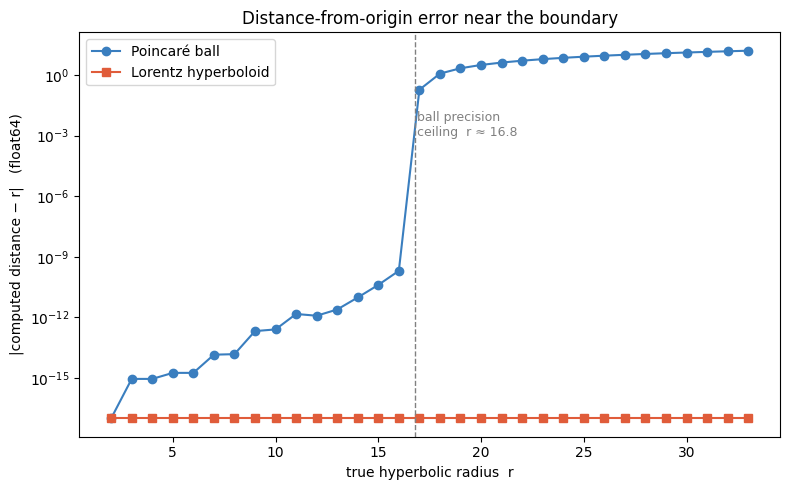

In [4]:
radii = np.arange(2, 34, 1.0)
err_poincare, err_lorentz = [], []
origin_ball = torch.tensor([[0.0, 0.0]])
origin_hyp = torch.tensor([[1.0, 0.0, 0.0]])
for r in radii:
    # same point, expressed in each model
    ball = torch.tensor([[np.tanh(r / 2), 0.0]])              # rho = tanh(r/2) -> 1
    hyp = torch.tensor([[np.cosh(r), np.sinh(r), 0.0]])       # x0 = cosh(r)
    err_poincare.append(abs(float(POINCARE_BALL.dist(ball, origin_ball)) - r))
    err_lorentz.append(abs(float(LORENTZ.dist(hyp, origin_hyp)) - r))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(radii, np.array(err_poincare) + 1e-17, "o-", label="Poincaré ball", color="#3a7ebf")
ax.semilogy(radii, np.array(err_lorentz) + 1e-17, "s-", label="Lorentz hyperboloid", color="#e05c3a")
ax.axvline(16.8, ls="--", color="grey", lw=1)
ax.text(16.9, 1e-3, "ball precision\nceiling  r ≈ 16.8", color="grey", fontsize=9)
ax.set_xlabel("true hyperbolic radius  r")
ax.set_ylabel("|computed distance − r|   (float64)")
ax.set_title("Distance-from-origin error near the boundary")
ax.legend()
plt.tight_layout()
plt.show()

The Poincaré error grows exponentially with radius and then **saturates**: past
$r\approx 16.8$ the ball reports the *same* distance ($\approx 16.81$) for every
deeper point — they have collapsed onto one another. The Lorentz distance stays
exact to machine precision throughout. This is the numerical instability the
Lorentz model was introduced to avoid, shown here independently of any
optimiser.

## What this means in practice

- **For most graphs, pick either.** The soft-ranking objective only needs *local*
  neighbour ordering, so it rarely drives nodes past the precision ceiling; on the
  tree above the two charts are interchangeable. In hypeGRL they also share the
  same Riemannian-Adam optimiser, so there is no optimiser-driven gap either.
- **Reach for Lorentz when the hierarchy is deep.** Very deep taxonomies (or any
  task that needs *faithful large distances* rather than just neighbour ranking)
  push leaves past $r\approx 16.8$, where the Poincaré ball can no longer tell them
  apart in ``float64`` and the Lorentz representation keeps full precision.
- **The trade-off.** The hyperboloid buys that precision with unbounded
  coordinates ($x_0=\cosh r$), which would overflow during optimisation — hypeGRL's
  :class:`~hypegrl.manifolds.lorentz.StableLorentz` clamps them to stay safe. The
  Poincaré ball is bounded by construction but precision-capped near its boundary.
  Same objective, complementary numerics.